# Extracción de perfiles del International Multi-Tokamak Confinement Profile Database

In [1]:
import MDSplus
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Conexión a la base de Datos
conn = MDSplus.Connection('tokamak-profiledb.ccfe.ac.uk')
conn.openTree('pr08_t10', 47800)

In [3]:
amin = conn.get(r'\top.zerod:amin').data()
#rmag = conn.get(r'\top.zerod:rmag').data()
#zmag = conn.get(r'\top.zerod:zmag').data()
#rgeo = conn.get(r'\top.zerod:rgeo').data()

In [4]:
# Obtención de los perfiles T y n como F(r,t)
Te = conn.get(r'\top.twod:te').data()
qe1= conn.get(r'\top.twod:qeche').data()
qe2= conn.get(r'\top.twod:qrad').data()
#qe3= conn.get(r'\top.twod:qei').data()
qe5 = conn.get(r'\top.twod:qohm').data()
ne = conn.get(r'\top.twod:ne').data()
B = conn.get(r'\top.zerod:bt')

In [5]:
(Te[0].max() - Te[0].min()) * (ne[0].max() - ne[0].min()) * 1e-6

3.930324526943999e+16

In [6]:
t = conn.get(r'dim_of(\top.twod:te,1)').data()
rho = conn.get(r'dim_of(\top.twod:te,0)').data() 

In [7]:
Te_unit = conn.get(r'units_of(\top.twod:te)').data()
ne_unit = conn.get(r'units_of(\top.twod:ne)').data()
qe5_unit = conn.get(r'units_of(\top.twod:qeche)').data()
t_unit  = conn.get(r'units_of(dim_of(\top.twod:te,1))').data()
r_unit  = conn.get(r'units_of(dim_of(\top.twod:te,0))').data()

In [8]:
Te_unit

'eV'

In [9]:
Te.shape

(2, 41)

In [10]:
#T = np.average(Te, axis=0)
#n = np.average(ne, axis=0)
T = Te[1]
n = ne[1]
#T = np.average(Te, axis=0)
#n = np.average(ne, axis=0)
That = np.copy((T - T.min()) / (T.max() - T.min()))
nhat = np.copy((n - n.min()) / (n.max() - n.min()))
print(qe5)
print(Te[1].max())
print(t)
#TD = Te / (Te.max() - Te.min())
qhat1 = np.copy((qe1 - qe1.min()) / (qe1.max() - qe1.min()))
#qhat2 = np.copy((qe2 - qe2.min()) / (qe2.max() - qe2.min()))
#qhat3 = np.copy((qe3 - qe3.min()) / (qe3.max() - qe3.min()))
#qe4 = 2.305e-34 * ne[0:-1]**2 / np.sqrt(Te[0:-1])
#qhat4 = np.copy((qe4 - qe4.min()) / (qe4.max() - qe4.min()))
#qhat5 = np.copy((qe5 - qe5.min()) / (qe5.max() - qe5.min()))

[[4.043434e+05 3.971421e+05 3.862037e+05 3.725845e+05 3.557370e+05
  3.367042e+05 3.166495e+05 2.959191e+05 2.750878e+05 2.542295e+05
  2.337808e+05 2.142966e+05 1.963666e+05 1.795410e+05 1.637590e+05
  1.487861e+05 1.343350e+05 1.201659e+05 1.066450e+05 9.422925e+04
  8.284034e+04 7.221610e+04 6.217235e+04 5.269336e+04 4.388962e+04
  3.573795e+04 2.851459e+04 2.248482e+04 1.739900e+04 1.324654e+04
  9.954447e+03 7.354124e+03 5.446733e+03 3.998239e+03 2.945892e+03
  2.235759e+03 1.739076e+03 1.387771e+03 1.191579e+03 1.011109e+03
  6.375046e-01]
 [5.125356e+04 5.040538e+04 4.908105e+04 4.735453e+04 4.504560e+04
  4.235335e+04 3.951985e+04 3.665729e+04 3.383105e+04 3.108280e+04
  2.843390e+04 2.590565e+04 2.353965e+04 2.126269e+04 1.903952e+04
  1.686887e+04 1.478724e+04 1.282878e+04 1.100325e+04 9.343163e+03
  7.853520e+03 6.515342e+03 5.354899e+03 4.349031e+03 3.503341e+03
  2.812271e+03 2.228066e+03 1.760775e+03 1.364552e+03 1.039017e+03
  7.724494e+02 5.612006e+02 4.157322e+02 3.047

5.13e+04


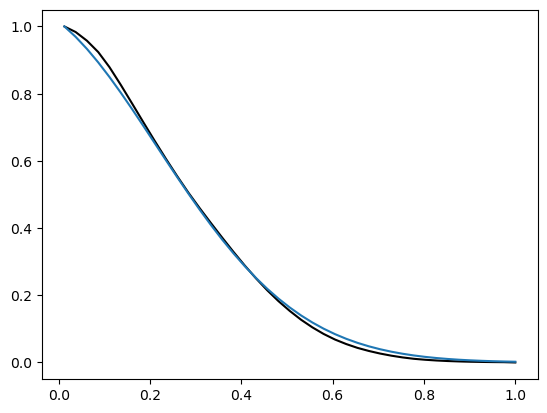

In [27]:
qhat = (qe5[1] - qe5[1].min()) / (qe5[1].max() - qe5[1].min())
s = 0.313
arr = np.exp(-0.5 * ((rho + 0.1) / s)**2) / (np.sqrt(2 * np.pi) * s)
arr *= (qe5[1].max() / arr.max())
plt.plot(rho, qe5[1] / qe5[1].max(), color="black")
plt.plot(rho, arr / arr.max())
max = qe5[1].max()
print(f'{max:.2e}')

In [538]:
#assert Te.shape == (len(t), len(r)), f"Unexpected Te shape: {Te.shape}, t={len(t)}, r={len(r)}"
#assert ne.shape == (len(t), len(r)), f"Unexpected Te shape: {ne.shape}, t={len(t)}, r={len(r)}"

In [539]:
#t0 = 9.6
#itime = np.argmin(np.abs(t - t0))

In [540]:
#Te_r = Te[itime, :]
#ne_r = ne[itime, :]
"""sum = (qe1 + qe2 + qe3 + qe5)
#print(f"{sum}")

def f(rho):
    A1, mu1, s1 = 11.08561484, 0.09780836, 0.41682358
    A2, mu2, s2 = 37.85138942, 0.49193007, 0.08961579
    A3, mu3, s3 = 0.66483884, 0.87163258, 0.06679503
    g = lambda A, mu, s: A * np.exp(-(rho - mu)**2 / (2 * s**2))
    return (g(A1, mu1, s1) + g(A2, mu2, s2) + g(A3, mu3, s3)) * 6.24e12

shat = np.copy((sum - sum.min()) / (sum.max() - sum.min()))
sfit = f(rho)
shat_fit = np.copy((sfit - sfit.min()) / (sfit.max() - sfit.min()))"""

'sum = (qe1 + qe2 + qe3 + qe5)\n#print(f"{sum}")\n\ndef f(rho):\n    A1, mu1, s1 = 11.08561484, 0.09780836, 0.41682358\n    A2, mu2, s2 = 37.85138942, 0.49193007, 0.08961579\n    A3, mu3, s3 = 0.66483884, 0.87163258, 0.06679503\n    g = lambda A, mu, s: A * np.exp(-(rho - mu)**2 / (2 * s**2))\n    return (g(A1, mu1, s1) + g(A2, mu2, s2) + g(A3, mu3, s3)) * 6.24e12\n\nshat = np.copy((sum - sum.min()) / (sum.max() - sum.min()))\nsfit = f(rho)\nshat_fit = np.copy((sfit - sfit.min()) / (sfit.max() - sfit.min()))'

In [93]:
import pandas as pd

dt = pd.read_csv('../../data/profile/20260628124411.dat', sep=' ', header=None, comment='#')
tm = dt[2].to_numpy()
nm = dt[1].to_numpy()
rm = dt[0].to_numpy()

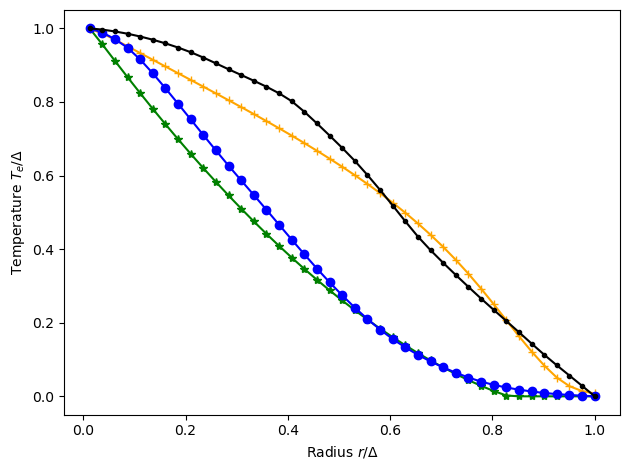

In [94]:
plt.figure()
#plt.plot(rho, qe1, marker='+', linestyle='-', color='orange')
#plt.plot(rho, qe2, marker='+', linestyle='-', color='blue')
#plt.plot(rho, qe3, marker='+', linestyle='-', color='black')
#plt.plot(rho, qe5, marker='+', linestyle='-', color='green')
plt.plot(rho, tm, marker='*', linestyle='-', color='green')
plt.plot(rho, nm, marker='+', linestyle='-', color='orange')
plt.plot(rho, That, marker='o', linestyle='-', color='blue')
plt.plot(rho, nhat, marker='.', linestyle='-', color='black')
plt.xlabel(r"Radius $r / \Delta$")
plt.ylabel("Temperature $T_e / \Delta$")
#plt.title(r"$\hat{T}_e(\rho)$ at t = " + f"{t[0]:.3f} {t_unit}")
plt.tight_layout()
plt.show()

In [95]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [96]:
#plt.ylim([0,14])
en = 100 * np.exp(np.log(np.abs(nm - nhat)[0:-1]) - np.log(np.abs(nhat)[0:-1]))
et = 100 * np.exp(np.log(np.abs(tm - That)[0:-1]) - np.log(np.abs(That)[0:-1]))

In [98]:
print(mean_absolute_error(tm, That))
print(np.sqrt(mean_squared_error(tm, That)))
print(np.abs(tm-That).max())
print(r2_score(tm, That))
np.mean(tm - That)

0.03589580148741885
0.05039054474255754
0.09763938922834892
0.9745338058282265


-0.03487244521712147

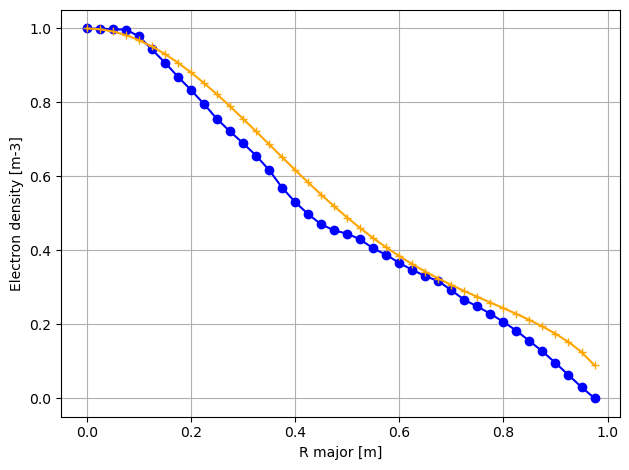

In [189]:
plt.figure()
plt.plot(rho, nhat, marker='o', linestyle='-', color='blue')
plt.plot(rho, den, marker='+', linestyle='-', color='orange')
plt.xlabel(r"R major [m]")
plt.ylabel(f"Electron density [{ne_unit}]")
#plt.title(rf"$n_e$(r) at t = {t[itime]:.3f} {t_unit}")
plt.grid(True)
plt.tight_layout()
plt.show()

In [124]:
with open("../../data/profile/errorcut_off.dat", "w") as f:
    for i in range(0, 40):
        print(rho[i], en[i], et[i], file=f, sep=' ')

In [90]:
t

array([0.55, 0.65])

In [ ]:
r[15]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def n_fit(x, a, b, c):
    return (1 - a) * (1 - x**2) ** b + a * np.sqrt(1 - c * x**2)

lower_bounds = [-np.inf, -np.inf, 0.0]  # Inferior cotes
upper_bounds = [ np.inf, np.inf, 1.0]  # Superior cotes

initial_guess = [0.4, 5.0, 0.5]
popt, pcov = curve_fit(n_fit, r, den, p0=initial_guess, bounds=(lower_bounds, upper_bounds), method='trf', absolute_sigma=True)
a_opt, b_opt, c_opt = popt
print(f"Fitted parameters:\na = {a_opt:.3f}\nb = {b_opt:.3f}\nc = {c_opt:.3f}")

plt.scatter(rho, nhat, color='blue', label='Experimental Data')
x_fit = np.linspace(0, 1, 40)
y_fit = n_fit(x_fit, *popt) 

plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Fitted Formula Curve')
plt.xlabel(r'$\rho$')
plt.ylabel(r'Densidad $\hat{n}$')
plt.legend()
plt.show()

In [ ]:
with open("fit.dat", "w") as f:
    for i in range(40):
        print(x_fit[i], y_fit[i], file=f, sep=' ')

In [ ]:
def T_fit(x, a, b, c):
    return a * ( (x / 0.375)**b * np.exp(1 - (x / 0.375)**b))**c

lower_bounds = [0.0, 0.0, 0.0]  # Inferior cotes
upper_bounds = [ 1.0, np.inf, np.inf]  # Superior cotes

initial_guess = [1.0, 0.03, 1.0]
popt, pcov = curve_fit(T_fit, r, tmp, p0=initial_guess, bounds=(lower_bounds, upper_bounds), method='trf', absolute_sigma=True)
a_opt, b_opt, c_opt = popt
print(f"Fitted parameters:\na = {a_opt:.3f}\nb = {b_opt:.3f}\nc = {c_opt:.3f}")

plt.scatter(rho, That, color='blue', label='Experimental Data')
x_fit = np.linspace(0, 0.975, 40)
y_fit = T_fit(x_fit, *popt) 

plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Fitted Formula Curve')
plt.xlabel(r'$\rho$')
plt.ylabel(r'Densidad $\hat{n}$')
plt.legend()
plt.show()